In [ ]:
import os
import sys
import h5py
# import yaml
# import types
# import torch
import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, REPO_ROOT)

## Load IT neuron firing rate

In [3]:
neural_data_pth = os.path.join(REPO_ROOT, 'data/forJhan/data/MergedITCells_500Stim_AxisTuned.mat')

with h5py.File(neural_data_pth, 'r') as f:
    responses = f['responses']
    # Build full (386 x 500) matrix once
    neural_matrix = np.stack([f[responses[0, i]][()].flatten() for i in range(386)])  # (386, 500)

## Encode stimuli images

### Load AlexNet fc6 embeddings (after PCA)

In [11]:
alexnet_fc6_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_alexnet_fc6_pca_latents/val_latents.npy"))

## Axis tuning analysis

For each of the 386 IT neurons, estimate its preferred axis in AlexNet fc6 (PCA'd) space, cross-validated explained variance along that axis, and a selectivity index comparing it to an orthogonal control axis.

In [12]:
from analysis.sta_analysis import (
    compute_population_axis_tuning,
    compute_orthogonal_variance,
    compute_sta,
)

In [ ]:
stimuli_embeddings = alexnet_fc6_latents

axis_tuning_results = compute_population_axis_tuning(
    neural_matrix, stimuli_embeddings, method='sta'
)

ev = axis_tuning_results['explained_variance']
sel = axis_tuning_results['selectivity_index']

print(f"Neurons: {neural_matrix.shape[0]}, Stimuli: {neural_matrix.shape[1]}, Feature dims: {alexnet_fc6_latents.shape[1]}")
print(f"Mean CV explained variance: {ev.mean():.3f} (median {np.median(ev):.3f})")
print(f"Mean selectivity index: {sel.mean():.3f} (median {np.median(sel):.3f})")
print(f"Neurons with EV > 0.1: {(ev > 0.1).sum()}/{len(ev)}")
print(f"Neurons with EV > 0.1 and selectivity > 0.5: {((ev > 0.1) & (sel > 0.5)).sum()}/{len(ev)}")
print(f"Mean pairwise preferred-axis angle: {axis_tuning_results['mean_pairwise_angle_deg']:.1f} deg")

Axis tuning (sta): 100%|██████████| 386/386 [01:09<00:00,  5.54it/s]

Neurons: 386, Stimuli: 500, Feature dims: 50
Mean CV explained variance: 0.168 (median 0.124)
Mean selectivity index: 1.000 (median 1.000)
Neurons with EV > 0.1: 231/386
Neurons with EV > 0.1 and selectivity > 0.5: 231/386
Mean pairwise preferred-axis angle: 61.7 deg


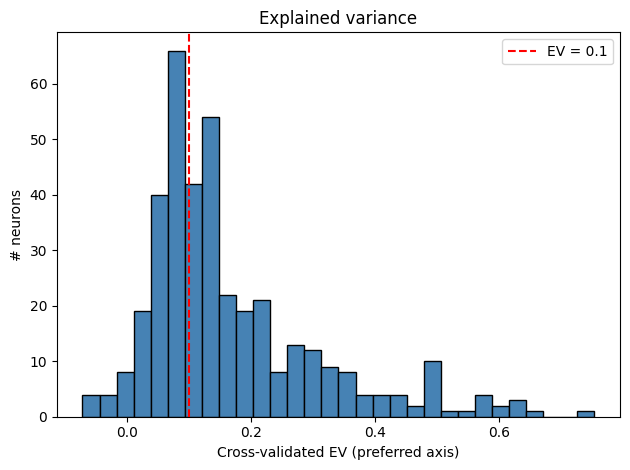

In [21]:
# fig, axes_ = plt.subplots(1, 3, figsize=(15, 4))

# axes_[0].hist(ev, bins=30, color='steelblue', edgecolor='black')
# axes_[0].axvline(0.1, color='red', linestyle='--', label='EV = 0.1')
# axes_[0].set_xlabel('Cross-validated EV (preferred axis)')
# axes_[0].set_ylabel('# neurons')
# axes_[0].set_title('Explained variance')
# axes_[0].legend()

# axes_[1].hist(sel, bins=30, color='seagreen', edgecolor='black')
# axes_[1].axvline(0.5, color='red', linestyle='--', label='selectivity = 0.5')
# axes_[1].set_xlabel('Selectivity index')
# axes_[1].set_title('Axis selectivity')
# axes_[1].legend()

# axes_[2].scatter(ev, sel, alpha=0.6, s=20, c=sel, cmap='RdYlGn')
# axes_[2].axhline(0.5, color='red', linestyle='--', linewidth=1)
# axes_[2].axvline(0.1, color='blue', linestyle='--', linewidth=1)
# axes_[2].set_xlabel('Explained variance')
# axes_[2].set_ylabel('Selectivity index')
# axes_[2].set_title('EV vs. selectivity')

plt.hist(ev, bins=30, color='steelblue', edgecolor='black')
plt.axvline(0.1, color='red', linestyle='--', label='EV = 0.1')
plt.xlabel('Cross-validated EV (preferred axis)')
plt.ylabel('# neurons')
plt.title('Explained variance')
plt.legend()

plt.tight_layout()
plt.show()

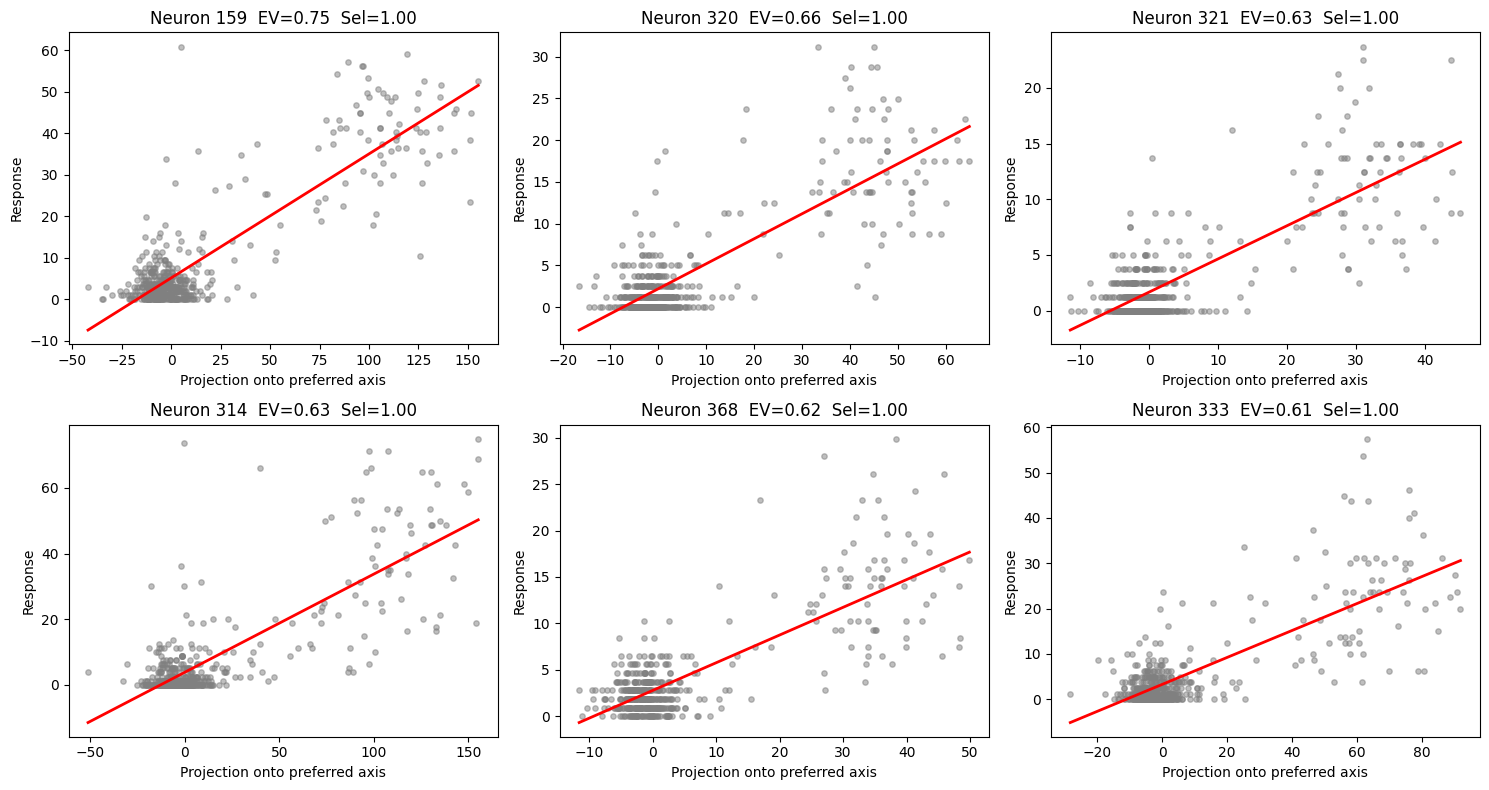

In [15]:
top_units = np.argsort(ev)[-6:][::-1]

fig, axes_ = plt.subplots(2, 3, figsize=(15, 8))
for ax, unit_idx in zip(axes_.flatten(), top_units):
    resp = neural_matrix[unit_idx, :]
    axis, _ = compute_sta(resp, alexnet_fc6_latents, method='sta', normalize=True)
    orth = compute_orthogonal_variance(resp, alexnet_fc6_latents, axis)
    proj_pref = orth['proj_pref']

    coeffs = np.polyfit(proj_pref, resp, 1)
    x_sorted = np.sort(proj_pref)
    ax.scatter(proj_pref, resp, alpha=0.5, s=15, color='gray')
    ax.plot(x_sorted, np.polyval(coeffs, x_sorted), 'r-', linewidth=2)
    ax.set_title(f"Neuron {unit_idx}  EV={ev[unit_idx]:.2f}  Sel={sel[unit_idx]:.2f}")
    ax.set_xlabel('Projection onto preferred axis')
    ax.set_ylabel('Response')

plt.tight_layout()
plt.show()